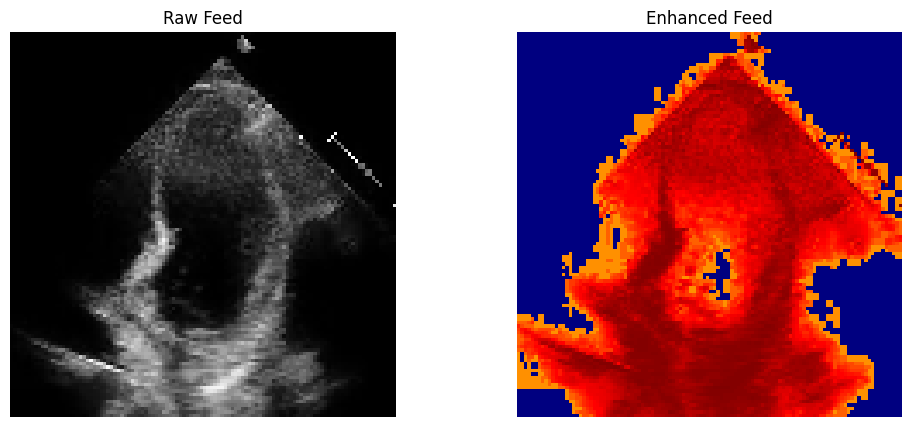

Video finished.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

cap = cv2.VideoCapture('echo.avi')

if not cap.isOpened():
    print("Error: Video not found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # histogram equalization
        equalized = cv2.equalizeHist(gray)

        # heatmap for blood flow
        heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

        # color balance adjustment
        balanced = heatmap.astype(np.float32)
        balanced[:, :, 0] *= 0.9
        balanced[:, :, 2] *= 1.1
        balanced = np.clip(balanced, 0, 255).astype(np.uint8)

        # log transform for dark regions
        gray_float = equalized.astype(np.float64)
        c = 255 / np.log(1 + np.max(gray_float))
        log_img = c * np.log(1 + gray_float)
        log_img = np.uint8(log_img)

        # gamma correction to suppress bright noise
        gamma = 0.6
        gamma_img = np.array(255 * (log_img / 255.0) ** gamma, dtype=np.uint8)
        enhanced_final = cv2.applyColorMap(gamma_img, cv2.COLORMAP_JET)
        enhanced_rgb = cv2.cvtColor(enhanced_final, cv2.COLOR_BGR2RGB)

        # update display
        axes[0].clear()
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title('Raw Feed')
        axes[0].axis('off')

        axes[1].clear()
        axes[1].imshow(enhanced_rgb)
        axes[1].set_title('Enhanced Feed')
        axes[1].axis('off')

        clear_output(wait=True)
        display(fig)

    cap.release()
    plt.close()
    print("Video finished.")